In [1]:
import pandas as pd
import numpy as np
import pyarrow
from sklearn.model_selection import  train_test_split
from keras.models import Sequential
from keras.layers import Dense, Input, Dropout
from keras import optimizers
import keras
import tensorflow as tf
from src import *

# Configurações 
print(tf.config.list_physical_devices())
BATCH_SIZE = 1024

[PhysicalDevice(name='/physical_device:CPU:0', device_type='CPU')]


## **Função para encontrar o número máximo de neurônio**

In [2]:
def num_max_neuronio(X, d):
    CT = len(X)
    return int((CT - 10)/(10 * (d + 2)))

## **Leitura dos dados e adaptações necessárias para a rede neural**

In [3]:
colunas = (
        [f'questao_{i}_LC' for i in range(1, 46)] +
        [f'questao_{i}_CH' for i in range(1, 46)] +
        [f'questao_{i}_CN' for i in range(1, 46)] +
        [f'questao_{i}_MT' for i in range(1, 46)] +
        ['NU_ANO']
    )
df = pd.read_parquet('dados acertos', columns=colunas)

In [4]:
df = calcular_acertos_por_area(df)

In [5]:
df['TOTAL_ACERTOS_GERAL'] = df['ACERTOS_LC'] + df['ACERTOS_MT'] + df['ACERTOS_CH'] + df['ACERTOS_CN'] 

df['CLASSE'] = df.groupby('NU_ANO')['TOTAL_ACERTOS_GERAL'].transform(lambda x: pd.qcut(x, q=3, labels=[0, 1, 2])).astype('Int64')
    
df['CLASSE'] = df['CLASSE'].astype(int)

In [6]:
df_reduzido = df.sample(n=100_000, random_state=42)
    
features = (
        [f'questao_{i}_LC' for i in range(1, 46)] +
        [f'questao_{i}_CH' for i in range(1, 46)] +
        [f'questao_{i}_CN' for i in range(1, 46)] +
        [f'questao_{i}_MT' for i in range(1, 46)] +
        ['ACERTOS_LC', 'ACERTOS_CH', 'ACERTOS_CN', 'ACERTOS_MT']
    )

X = df_reduzido[features]
y = df_reduzido['CLASSE']


## **Separando os dados**

In [7]:
x_train, x_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)
x_train, x_val, y_train, y_val = train_test_split(x_train, y_train, test_size=0.2, random_state=42)

## **Normalizando os dados**

In [8]:
from sklearn.preprocessing import MinMaxScaler

scaler = MinMaxScaler()

x_train = scaler.fit_transform(x_train).astype(np.float32)
x_val   = scaler.transform(x_val).astype(np.float32)
x_test  = scaler.transform(x_test).astype(np.float32)

In [9]:
# Analisando os dados do rotulo de treinamento
print("Tipo:", y_train.dtype)
print("Valores únicos:", np.unique(y_train))
print("Amostra:", y_train[:10])

Tipo: int64
Valores únicos: [0 1 2]
Amostra: 45341      1
515600     2
1074713    0
1033333    1
2972458    0
3140154    0
4030304    1
405041     1
1901505    2
1239164    2
Name: CLASSE, dtype: int64


## **Construindo a rede neural**

In [10]:
max_neurons = num_max_neuronio(x_train, d = 1)
print("Número máximo de neurônios:", max_neurons)

Número máximo de neurônios: 2133


In [11]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Dropout
from tensorflow.keras import regularizers
from tensorflow.keras.callbacks import EarlyStopping
import numpy as np

model = Sequential()
model.add(Dense(100, input_dim=184,
                kernel_initializer='he_normal',
                kernel_regularizer=regularizers.l2(0.0001),
                activation='relu'))
model.add(Dropout(0.2))
model.add(Dense(100, kernel_initializer='he_normal',
                kernel_regularizer=regularizers.l2(0.0001),
                activation='relu'))
model.add(Dropout(0.2))

# Camada de saída
model.add(Dense(3, kernel_initializer='he_normal', activation='softmax'))

model.compile(loss='sparse_categorical_crossentropy',
              optimizer='adam',
              metrics=['accuracy'])

es = EarlyStopping(monitor='val_loss', mode='min', patience=10, verbose=1)

history = model.fit(
    x_train, y_train,
    epochs=5,
    batch_size=32,
    validation_data=(x_val, y_val),
    callbacks=[es],
    verbose=1
)

c:\Users\Micael\AppData\Local\Programs\Python\Python313\Lib\site-packages\keras\src\layers\core\dense.py:106: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Epoch 1/5
2000/2000 ━━━━━━━━━━━━━━━━━━━━ 5s 2ms/step - accuracy: 0.7684 - loss: 0.5439 - val_accuracy: 0.8852 - val_loss: 0.3141
Epoch 2/5
2000/2000 ━━━━━━━━━━━━━━━━━━━━ 4s 2ms/step - accuracy: 0.8683 - loss: 0.3360 - val_accuracy: 0.8909 - val_loss: 0.2783
Epoch 3/5
2000/2000 ━━━━━━━━━━━━━━━━━━━━ 3s 2ms/step - accuracy: 0.8959 - loss: 0.2734 - val_accuracy: 0.9051 - val_loss: 0.2447
Epoch 4/5
2000/2000 ━━━━━━━━━━━━━━━━━━━━ 3s 2ms/step - accuracy: 0.9092 - loss: 0.2403 - val_accuracy: 0.9187 - val_loss: 0.2150
Epoch 5/5
2000/2000 ━━━━━━━━━━━━━━━━━━━━ 3s 2ms/step - accuracy: 0.9199 - loss: 0.2162 - val_accuracy: 0.9208 - val_loss: 0.2094


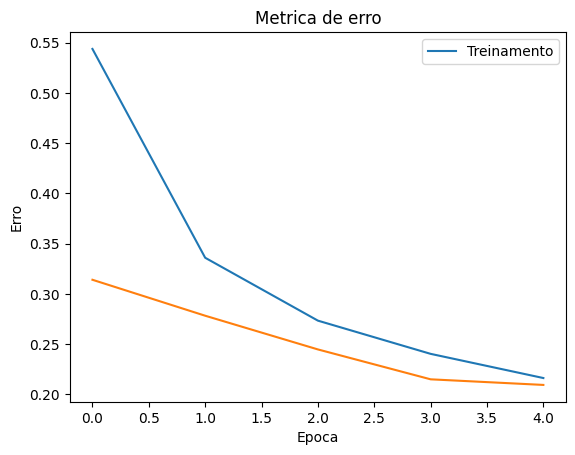

16/16 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.9208 - loss: 0.2094 

--> Acuracia (treino): 0.9519
--> Acuracia (validacao): 0.9208
--> E_val - E_in = 0.0542
--> acc_train - acc_val = 0.0311


In [12]:
from sklearn.metrics import accuracy_score
import matplotlib.pyplot as plt

plt.plot(history.history['loss'])
plt.plot(history.history['val_loss'], label='Validação')
plt.title('Metrica de erro')
plt.ylabel('Erro')
plt.xlabel('Epoca')
plt.legend(['Treinamento'])
plt.show()

# Obtendo a acuracia no conjunto de treinamento
E_in, acc_train = model.evaluate(x_train, y_train, batch_size=BATCH_SIZE, verbose=0)

# Obtendo a acuracia no conjunto de validação
E_val, acc_val = model.evaluate(x_val, y_val, batch_size=BATCH_SIZE)

print(f'\n--> Acuracia (treino): {acc_train:.4f}')
print(f'--> Acuracia (validacao): {acc_val:.4f}')
print(f"--> E_val - E_in = {E_val - E_in:.4f}")
print(f"--> acc_train - acc_val = {acc_train - acc_val:.4f}")